In [1]:
from CLEAR_2nd_line import *
import numpy as np
import matplotlib.pyplot as plt
import RF_Track as rft
# from scipy.optimize import minimize, curve_fit
from scipy.stats import norm
# from partrec_gaussian_optimiser_utils import partrec_gaussian_optimiser_utils
# from topasToDose import getDosemap
from uniformity_fit import *
# from partrec_foil_plotting import partrec_foil_plotting
# from RF_track_utils import *
# from flatness import *


RF-Track, version 2.5.5

Copyright (C) 2016-2025 CERN, Geneva, Switzerland. All rights reserved.

Author and contact:
 Andrea Latina <andrea.latina@cern.ch>
 BE-ABP Group
 CERN
 CH-1211 GENEVA 23
 SWITZERLAND

This software is distributed under a CERN proprietary software
license in the hope that it will be useful, but WITHOUT ANY WARRANTY;
not even for MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE.

See the COPYRIGHT and LICENSE files at the top-level directory of
the RF-Track download area: https://gitlab.cern.ch/rf-track

RF-Track was compiled with GSL-2.8 and fftw-3.3.10



[RF-Track] Could not check for updates.


In [2]:
def get_s2_params(max_radius, max_thickness, N_slices, convolution_factor):
    s2_sigma = max_radius / 2
    step = max_radius / N_slices

    # Radial positions
    x = np.arange(-(max_radius + step), 0, step=step)

    # Thickness profile
    y = norm.pdf(x, 0, s2_sigma * convolution_factor)
    y = y - np.min(y)
    y *= max_thickness / np.max(y)
    # plt.scatter(x, y)
    slice_widths = np.diff(y) #thicknesses of each slice in L
    slice_radii = np.abs(x[1:])   # Corresponding radii (height)

    return slice_radii, slice_widths

In [3]:

mass = rft.electronmass    # particle mass in MeV/c^2
population = 10 * rft.nC               # number of particles per bunch                         # particle charge in e units
P_ref = 200
N_particles = int(100000)
charge = -1

Twiss = rft.Bunch6d_twiss()




Twiss.beta_x = 20        # m
Twiss.beta_y = 20     # m
Twiss.alpha_x = 0.0
Twiss.alpha_y = 0.0
Twiss.emitt_x = 10    # mm.mrad normalised emittance
Twiss.emitt_y = 10     # mm.mrad    


# Twiss.sigma_t = 10 * RF_Track.ps       # mm/c   or 37 * RF_Track.ps
# Twiss.sigma_pt = 10     # permille
Twiss.mean_xp = 0.0
Twiss.mean_yp = 0.0

B0 = rft.Bunch6d_QR(mass, population, charge, P_ref, Twiss, N_particles)      



In [22]:
lattice_description = get_2nd_beamline("CLEAR_2nd_Beamline_Survey.txt")
CLEAR_2_lattice = build_rft_lattice(lattice_description,
        start =  "CS.2NDBL$START" ,           # tbc where to start, maybe from first quad 350? 
        end = "CS.BTV0420",
        P_ref = 198,
        quad_currents = [0]*6,
        Q=1,
        include_end=True)
print(CLEAR_2_lattice.get_length())

s1_l, s2_width, s2_depth = 1, 1.5,3

CLEAR_2_lattice.append(rft.Drift(2.243))  #drift to S1
# S1 = rft.Absorber(s1_l/1000,8.897, 13,26.982,2.7, 166)
S1 = rft.Absorber(s1_l/1000,'beryllium')
S1.disable_energy_straggling()
S1.set_shape ('circular', 1,1 )
CLEAR_2_lattice.append(S1)

CLEAR_2_lattice.append(rft.Drift(0.563))  #drift to S2

s2_r,s2_l = get_s2_params(s2_width, s2_depth, 4, 1)


for i in range(len(s2_l)):
    Slice = rft.Absorber(s2_l[i]/1000,31.9, 37, 288.31,1.32,-1)
    Slice.disable_energy_straggling()
    Slice.set_shape ('circular',  abs(s2_r[i])/1000,abs(s2_r[i])/1000 )
    CLEAR_2_lattice.append(Slice)

CLEAR_2_lattice.append(rft.Drift(2.45))  #drift to YAG

B1 = CLEAR_2_lattice.track(B0)
T = CLEAR_2_lattice.get_transport_table(
'%S %beta_x %beta_y %alpha_x %alpha_y %sigma_x %sigma_y %sigma_px %sigma_py')
M = B1.get_phase_space('%x %xp %y %yp %E %z')
print(CLEAR_2_lattice.get_length())


10.884400000000003
16.144400000000005


In [10]:
np.mean(M[:,0] ),np.mean(M[:,2] )
CLEAR_2_lattice.get_elements_by_name('S2')

[]

In [23]:
T[:,1]

array([20.00030193, 20.00030193, 20.00030194, 15.83647764, 15.85333129,
       15.86403006, 15.95181734, 15.95181734, 15.99834964, 16.06666217,
       16.19045672, 16.22144192, 16.59496956, 16.73291968, 17.61795722,
       17.82554493, 18.28310928, 18.36254786, 18.48014235, 18.57767056,
       18.80727424, 24.22619968, 24.37971831, 24.37971831, 24.5641161 ,
       24.66015405, 24.78649836, 25.08451206, 25.39152563, 25.70753906,
       26.03255236, 26.36656552, 26.9644808 , 27.10443778, 27.24699097,
       27.36787855, 28.0164118 , 28.0164118 , 31.10799089, 31.10947492,
       31.96451491, 31.96502132, 31.96607267, 31.96763295, 31.9691604 ,
       36.05984958])

1


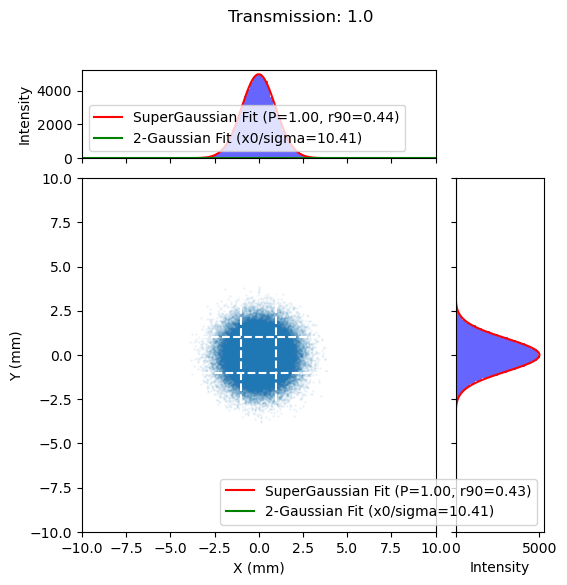

In [8]:
M[:,0] = M[:,0] - np.mean(M[:,0])
M[:,2] = M[:,2] - np.mean(M[:,2])
x = M[:,0]
y = M[:,2]
count = np.sum(x**2 + y**2 < 10**2)
transmission_10mm = count / len(x)
plot_phsp(T,M,120,10,title="Transmission: "+str(round(transmission_10mm,3)))

In [26]:
lattice_description = get_2nd_beamline("CLEAR_2nd_Beamline_Survey.txt")
CLEAR_2_lattice = build_rft_lattice(lattice_description,
        start =  "CS.2NDBL$START" ,           # tbc where to start, maybe from first quad 350? 
        end = "CS.BTV0420",
        P_ref = 198,
        quad_currents = [0]*6,
        Q=1,
        include_end=True)
print(CLEAR_2_lattice.get_length())

s1_l, s2_width, s2_depth = 1, 1.5,3

CLEAR_2_lattice.append(rft.Drift(2.243))  #drift to S1
# S1 = rft.Absorber(s1_l/1000,8.897, 13,26.982,2.7, 166)
S1 = rft.Absorber(s1_l/1000,'air')
S1.disable_energy_straggling()
S1.set_shape ('circular', 1,1 )
CLEAR_2_lattice.append(S1)

CLEAR_2_lattice.append(rft.Drift(0.563))  #drift to S2

s2_r,s2_l = get_s2_params(s2_width, s2_depth, 4, 1)


for i in range(len(s2_l)):
    Slice = rft.Absorber(s2_l[i]/1000,'air')
    Slice.disable_energy_straggling()
    Slice.set_shape ('circular',  abs(s2_r[i])/1000,abs(s2_r[i])/1000 )
    CLEAR_2_lattice.append(Slice)

CLEAR_2_lattice.append(rft.Drift(2.45))  #drift to YAG

B1 = CLEAR_2_lattice.track(B0)
T = CLEAR_2_lattice.get_transport_table(
'%S %beta_x %beta_y %alpha_x %alpha_y %sigma_x %sigma_y %sigma_px %sigma_py')
M = B1.get_phase_space('%x %xp %y %yp %E %z')
print(CLEAR_2_lattice.get_length())

10.884400000000003
16.144400000000005


In [27]:
T[:,1]

array([20.00030193, 20.00030193, 20.00030194, 15.83647764, 15.85333129,
       15.86403006, 15.95181734, 15.95181734, 15.99834964, 16.06666217,
       16.19045672, 16.22144192, 16.59496956, 16.73291968, 17.61795722,
       17.82554493, 18.28310928, 18.36254786, 18.48014235, 18.57767056,
       18.80727424, 24.22619968, 24.37971831, 24.37971831, 24.5641161 ,
       24.66015405, 24.78649836, 25.08451206, 25.39152563, 25.70753906,
       26.03255236, 26.36656552, 26.9644808 , 27.10443778, 27.24699097,
       27.36787855, 28.0164118 , 28.0164118 , 31.10799089, 31.10947492,
       31.96451491, 31.96502132, 31.96607267, 31.96763295, 31.9691604 ,
       36.05984958])

In [ ]:
for i in range(30, 50):
    print(CLEAR_2_lattice[i], CLEAR_2_lattice[i].get_length(), CLEAR_2_lattice[i].get_offsets())

AttributeError: 'Quadrupole' object has no attribute 'get_type'

RuntimeError: <Swig Object of type 'std::out_of_range *' at 0x31059ebf0>